In [1]:
# modules
! pip install fiftyone
import fiftyone.zoo as foz
import os
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
from torch import nn
from torchvision import transforms
import torch.nn.functional as F
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
!pip install segmentation-models-pytorch
import segmentation_models_pytorch as smp

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.7/17.7 MB 112.5 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.8/112.8 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.5/112.5 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 159.3 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.6/101.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 8

/usr/local/lib/python3.12/dist-packages/glob2/fnmatch.py:141: SyntaxWarning: invalid escape sequence '\Z'
  return '(?ms)' + res + '\Z'


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.0 MB/s eta 0:00:00


In [2]:
# use GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

Using device: cuda


In [4]:
#### IMAGE TRANSFORMATIONS

# these RGB normalization parameters are not calculated for this dataset specifically, they come from Image Net dataset.
img_transformations = transforms.Compose([
                                      transforms.ToTensor(),
                                      transforms.Normalize(mean=[0.485, 0.456, 0.406],std=[0.229, 0.224, 0.225])
])


#### Defining model and dataset classes

In [5]:
##### UNET CLASS FROM SCRATCH

class UnetDown(nn.Module):
    def __init__(self, input_size, output_size):
        super(UnetDown, self).__init__()

        self.model = nn.Sequential(
            nn.BatchNorm2d(input_size),
            nn.ReLU(inplace=True),
            nn.Conv2d(input_size, output_size, kernel_size=3, stride=1, padding=1),
            nn.BatchNorm2d(output_size),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(output_size, output_size, kernel_size=3, stride=1, padding=1),
        )

    def forward(self, x):
        return self.model(x)


class UnetUp(nn.Module):
    def __init__(self, input_size, output_size):
        super(UnetUp, self).__init__()

        model = [nn.BatchNorm2d(input_size),
                 nn.ReLU(inplace=True),
                 nn.Conv2d(input_size, output_size, kernel_size=3, stride=1, padding=1),
                 nn.BatchNorm2d(output_size),
                 nn.ReLU(inplace=True),
                 nn.Upsample(scale_factor=2, mode="nearest"),
                 nn.Conv2d(output_size, output_size, kernel_size=3, stride=1, padding=1)]

        self.model = nn.Sequential(*model)

    def forward(self, x):
        return self.model(x)


class Unet(nn.Module):
    def __init__(self, channels_in, channels_out):
        super(Unet, self).__init__()

        self.conv_in = nn.Conv2d(channels_in, 64,
                                 kernel_size=3, stride=1, padding=1)

        self.down1 = UnetDown(64, 64)
        self.down2 = UnetDown(64, 128)
        self.down3 = UnetDown(128, 128)
        self.down4 = UnetDown(128, 256)

        self.up4 = UnetUp(256, 128)
        self.up5 = UnetUp(128 * 2, 128)
        self.up6 = UnetUp(128 * 2, 64)
        self.up7 = UnetUp(64 * 2, 64)

        self.conv_out = nn.Conv2d(64 * 2, channels_out,
                                  kernel_size=3, stride=1, padding=1)

    def forward(self, x):
        x0 = self.conv_in(x)

        x1 = self.down1(x0)
        x2 = self.down2(x1)
        x3 = self.down3(x2)
        x4 = self.down4(x3)

        # Bottle-neck
        x5 = self.up4(x4)

        x5_ = torch.cat((x5, x3), 1)
        x6 = self.up5(x5_)

        x6_ = torch.cat((x6, x2), 1)
        x7 = self.up6(x6_)

        x7_ = torch.cat((x7, x1), 1)
        x8 = self.up7(x7_)

        x8_ = F.relu(torch.cat((x8, x0), 1), inplace=True)
        return self.conv_out(x8_)

In [6]:
model_unet = Unet(channels_in=3, channels_out=4).to(device)

In [7]:
# pretrained deeplab v3+ model class
class DeepLabV3PlusModel(nn.Module):
    def __init__(self, num_classes=4):
        super(DeepLabV3PlusModel, self).__init__()
        self.model = smp.DeepLabV3Plus(
            encoder_name="resnet50",
            encoder_weights="imagenet",
            in_channels=3,
            classes=num_classes
        )

    def forward(self, x):
        return self.model(x)

In [8]:
model_deeplab = DeepLabV3PlusModel(num_classes=4).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [9]:
# DATASET CLASS
class openimages_dataset(Dataset):
    def __init__(self, fo_dataset, transform=None):
        self.samples = []
        self.transform = transform
        self.class_mapping = {"Bird": 1, "Bottle": 2, "Car": 3}

        for sample in fo_dataset:
            image_path = sample.filepath
            masks_info = []

            if sample.ground_truth is not None:
                for det in sample.ground_truth.detections:
                    if det.label in self.class_mapping and det.mask is not None:
                        masks_info.append({
                            'label': det.label,
                            'mask': det.mask,
                            'bbox': det.bounding_box
                        })

            self.samples.append({
                'path': image_path,
                'masks_info': masks_info,
                'filename': os.path.basename(image_path)
            })

        # count images per class
        class_counts = {1: 0, 2: 0, 3: 0}
        for sample in self.samples:
            present = set()
            for mask_info in sample['masks_info']:
                present.add(self.class_mapping[mask_info['label']])
            for class_id in present:
                class_counts[class_id] += 1

        print(f"Total {len(self.samples)} images")
        print(f"Bird:     {class_counts[1]} images")
        print(f"Bottle:   {class_counts[2]} images")
        print(f"Car: {class_counts[3]} images")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]

        image   = Image.open(sample['path']).convert('RGB')
        image   = image.resize((256, 256), Image.BILINEAR)
        gt_mask = np.zeros((256, 256), dtype=np.int64)

        for mask_info in sample['masks_info']:
            class_id = self.class_mapping[mask_info['label']]
            raw_mask = mask_info['mask']
            bbox     = mask_info['bbox']

            x = int(bbox[0] * 256)
            y = int(bbox[1] * 256)
            w = max(int(bbox[2] * 256), 1)
            h = max(int(bbox[3] * 256), 1)

            mask_pil   = Image.fromarray((raw_mask * 255).astype(np.uint8))
            mask_pil   = mask_pil.resize((w, h), Image.NEAREST)
            mask_array = np.array(mask_pil) > 128

            x2 = min(x + w, 256)
            y2 = min(y + h, 256)
            gt_mask[y:y2, x:x2][mask_array[:y2-y, :x2-x]] = class_id

        if self.transform:
            image = self.transform(image)

        return image, torch.tensor(gt_mask, dtype=torch.long)

#### Functions for training and visualization

In [10]:
def train_model(model, train_loader, val_loader, device,
                epochs=10, lr=0.001, patience=3,
                class_weights=None, save_path='best_model.pth'):

    if class_weights is not None:
        criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    else:
        criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss      = float('inf')
    train_losses       = []
    val_losses         = []
    early_stop_counter = 0
    diverging          = False

    for epoch in range(epochs):

        # ── TRAINING PHASE ────────────────────────────────────────────────────
        model.train()
        total_loss = 0

        for images, masks in tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]"):
            images, masks = images.to(device), masks.to(device)

            outputs = model(images)
            loss    = criterion(outputs, masks)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_train_loss = total_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # ── VALIDATION PHASE ──────────────────────────────────────────────────
        model.eval()
        val_loss   = 0
        all_preds  = []
        all_labels = []

        with torch.no_grad():
            for images, masks in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]"):
                images, masks = images.to(device), masks.to(device)

                outputs  = model(images)
                loss     = criterion(outputs, masks)
                val_loss += loss.item()

                preds  = torch.argmax(outputs, dim=1).cpu().numpy().flatten()
                labels = masks.cpu().numpy().flatten()
                all_preds.extend(preds)
                all_labels.extend(labels)

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        # ── METRICS ───────────────────────────────────────────────────────────
        valid    = np.array(all_labels) != 0

        accuracy = accuracy_score(np.array(all_labels)[valid], np.array(all_preds)[valid])

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")
        print(f"Val Accuracy: {accuracy:.4f}")

        # saving best model (smallest loss value)
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save(model.state_dict(), save_path)
            print(f"Saved best model with val loss: {best_val_loss:.4f}")
            early_stop_counter = 0
        else:
            early_stop_counter += 1
            print(f"No improvement for {early_stop_counter} epochs")

        # ── DIVERGENCE CHECK ──────────────────────────────────────────────────
        if len(train_losses) >= 2:
            if train_losses[-1] < train_losses[-2] and val_losses[-1] > val_losses[-2]:
                diverging = True
                print("Train-Val losses diverging!!")
            else:
                diverging = False

        # ── EARLY STOPPING ────────────────────────────────────────────────────
        if diverging and early_stop_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # ── LOAD BEST MODEL ───────────────────────────────────────────────────────
    model.load_state_dict(torch.load(save_path))
    print(f"\nTraining complete — best model loaded from {save_path}")

    return model, train_losses, val_losses

In [11]:
# functions for vis
classes = ['background', 'bird', 'bottle', 'car']
colors  = [(0,0,0), (255,0,0), (0,255,0), (0,0,255)]

# converts integer class mask to RGB color image
def decode_mask(mask):
    color_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for class_id, color in enumerate(colors):
        color_mask[mask == class_id] = color
    return color_mask

# undo the ImageNet normalization applied during training so image looks correct
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    image = tensor.permute(1, 2, 0).numpy()
    image = image * std + mean
    image = np.clip(image, 0, 1)
    return image

# vis image, gt mask, pred mask
def visualize_predictions(model, dataset, device, num_samples=5):
    model.eval()

    # randomly pick images from the dataset
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    for idx in indices:
        image, true_mask = dataset[idx]

        # run model on single image
        with torch.no_grad():
            output    = model(image.unsqueeze(0).to(device))  # add batch dimension
            pred_mask = torch.argmax(output.squeeze(), dim=0).cpu().numpy()

        # prepare image for display
        image_np      = denormalize(image)
        true_mask_np  = true_mask.numpy()

        # get class names present in each mask
        true_classes = [classes[i] for i in np.unique(true_mask_np) if i != 0]
        pred_classes = [classes[i] for i in np.unique(pred_mask)     if i != 0]

        # plot original image, ground truth mask, predicted mask side by side
        fig, axs = plt.subplots(1, 3, figsize=(15, 5))

        axs[0].imshow(image_np)
        axs[0].set_title("Original Image")
        axs[0].axis("off")

        axs[1].imshow(decode_mask(true_mask_np))
        axs[1].set_title(f"Ground Truth\n{', '.join(true_classes) or 'background only'}")
        axs[1].axis("off")

        axs[2].imshow(decode_mask(pred_mask))
        axs[2].set_title(f"Prediction\n{', '.join(pred_classes) or 'background only'}")
        axs[2].axis("off")

        # color legend
        legend_patches = [plt.Rectangle((0,0),1,1, color=[c/255 for c in color], label=cls)
                          for cls, color in zip(classes[1:], colors[1:])]  # skip background
        axs[2].legend(handles=legend_patches, loc='lower right', fontsize=8)

        plt.suptitle(f"Sample {idx}", fontsize=12)
        plt.tight_layout()
        plt.show()

# loss curve
def plot_loss_curves(train_losses, val_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Train Loss', marker='o')
    plt.plot(val_losses,   label='Val Loss',   marker='o')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

#### TRAINING

In [12]:
class_weights = torch.tensor([0.15, 1.0, 1.0, 1.0]) # for the background to not overdominate

In [13]:
# train dataset
train_fo_dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="train",
    label_types=["segmentations"],
    max_samples=5000,
    classes=["Bird", "Bottle", "Car"],
    only_matching=True,
    cleanup=True
)

INFO:fiftyone.zoo.datasets:Downloading split 'train' to '/root/fiftyone/open-images-v7/train' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/train/train-images-boxable-with-rotation.csv' to '/root/fiftyone/open-images-v7/train/metadata/image_ids.csv'


 100% |██████|    4.8Gb/4.8Gb [2.1s elapsed, 0s remaining, 2.3Gb/s]        


INFO:eta.core.utils: 100% |██████|    4.8Gb/4.8Gb [2.1s elapsed, 0s remaining, 2.3Gb/s]        


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/v5/class-descriptions-boxable.csv' to '/root/fiftyone/open-images-v7/train/metadata/classes.csv'


...

INFO:fiftyone.zoo.datasets:Loading 'open-images-v7' split 'train'


 100% |███████████████| 5000/5000 [4.0m elapsed, 0s remaining, 17.7 samples/s]      


INFO:eta.core.utils: 100% |███████████████| 5000/5000 [4.0m elapsed, 0s remaining, 17.7 samples/s]      


Dataset 'open-images-v7-train-5000' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v7-train-5000' created


In [14]:
train_dataset = openimages_dataset(train_fo_dataset, transform=img_transformations)

total_tr_samples = len(train_dataset)
tr_n  = int(0.8 * total_tr_samples)
val_n = total_tr_samples - tr_n

train_dataset, val_dataset = random_split(train_dataset, [tr_n, val_n])

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

Total 5000 images
Bird:     788 images
Bottle:   731 images
Car: 3483 images


In [15]:
### UNET TRAINING
unet_trained, train_losses, val_losses = train_model(
    model=model_unet,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=10,
    lr=0.001,
    class_weights=class_weights,
    save_path='best_unet_model.pth'
)

Epoch 1/10 [Val]: 100%|██████████| 125/125 [00:23<00:00,  5.34it/s]



Epoch 1/10
Train Loss: 0.9900 | Val Loss: 0.9290
Val Accuracy: 0.6016
Saved best model with val loss: 0.9290


Epoch 2/10 [Val]: 100%|██████████| 125/125 [00:23<00:00,  5.36it/s]



Epoch 2/10
Train Loss: 0.9110 | Val Loss: 0.9196
Val Accuracy: 0.5729
Saved best model with val loss: 0.9196


Epoch 3/10 [Val]: 100%|██████████| 125/125 [00:23<00:00,  5.40it/s]


...


Epoch 8/10
Train Loss: 0.7256 | Val Loss: 0.6943
Val Accuracy: 0.7451
Saved best model with val loss: 0.6943


Epoch 9/10 [Val]: 100%|██████████| 125/125 [00:23<00:00,  5.25it/s]



Epoch 9/10
Train Loss: 0.7090 | Val Loss: 0.6809
Val Accuracy: 0.6833
Saved best model with val loss: 0.6809


Epoch 10/10 [Val]: 100%|██████████| 125/125 [00:23<00:00,  5.31it/s]



Epoch 10/10
Train Loss: 0.6838 | Val Loss: 0.7244
Val Accuracy: 0.7317
No improvement for 1 epochs

Training complete — best model loaded from best_unet_model.pth


Loss curves U-Net


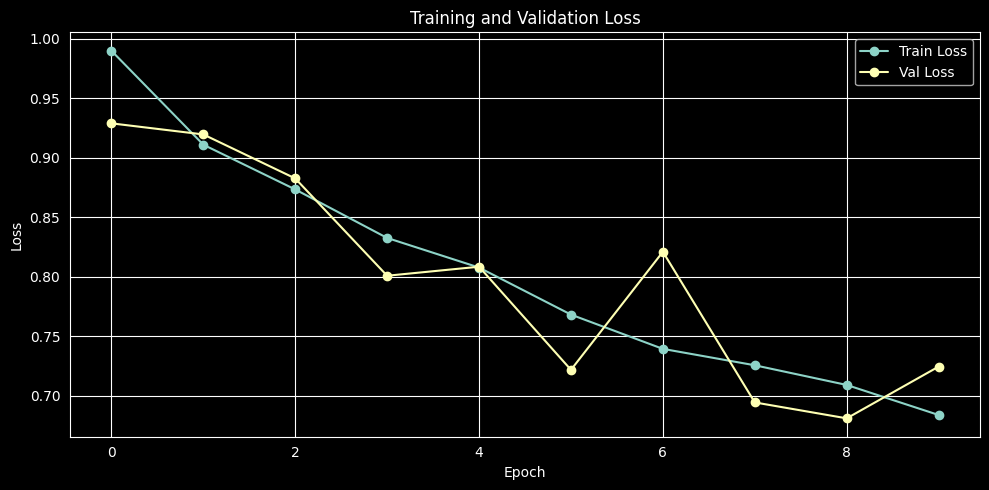

Visualizing predictions on validation set U-Net:


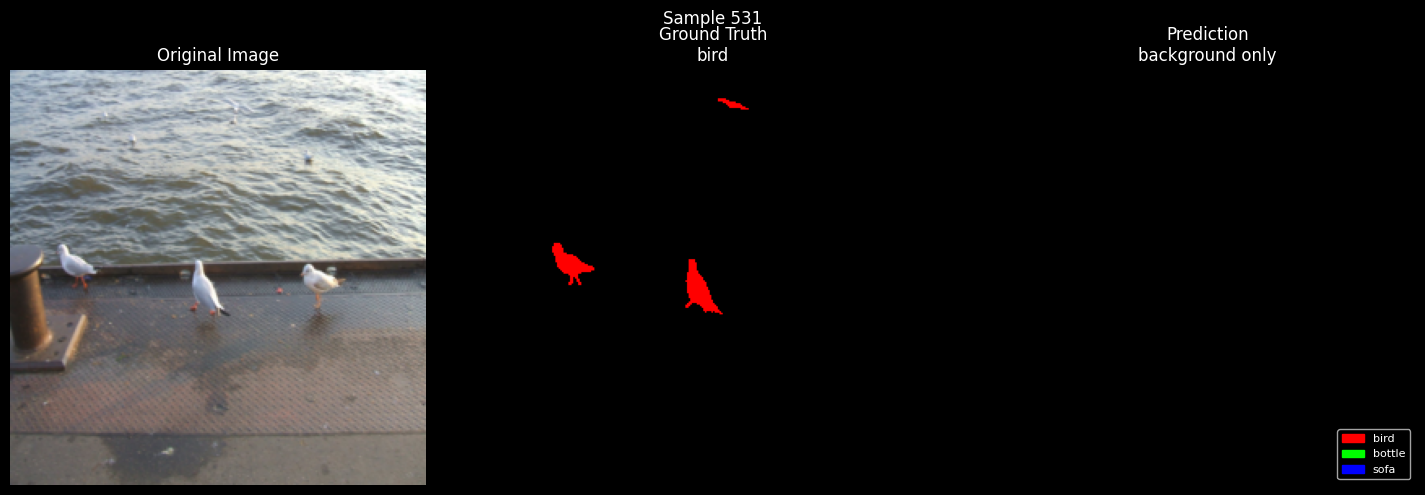

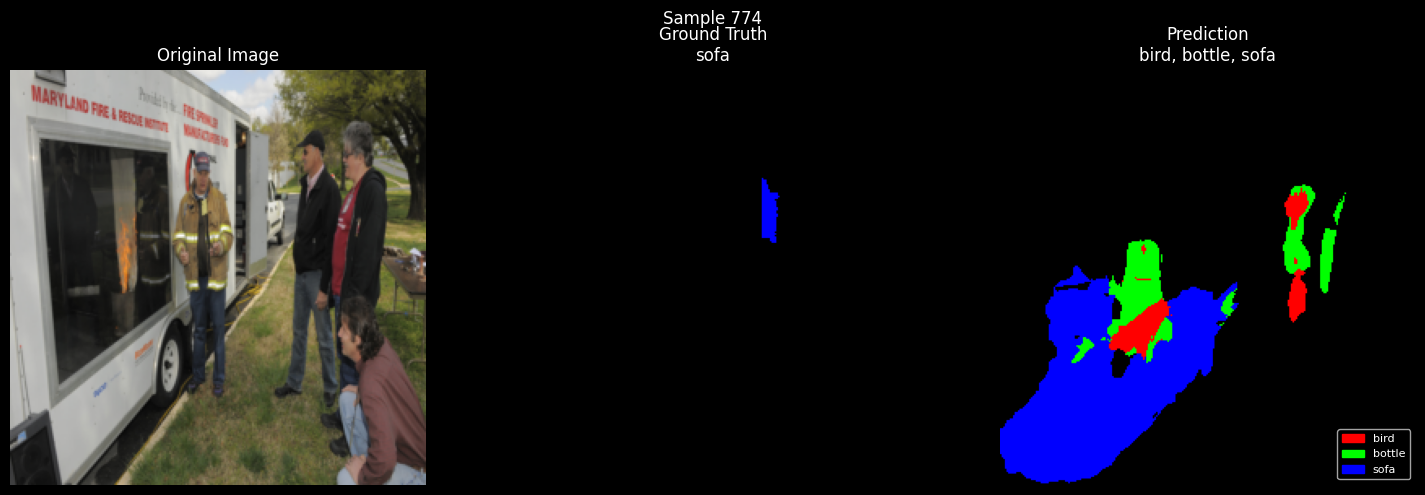

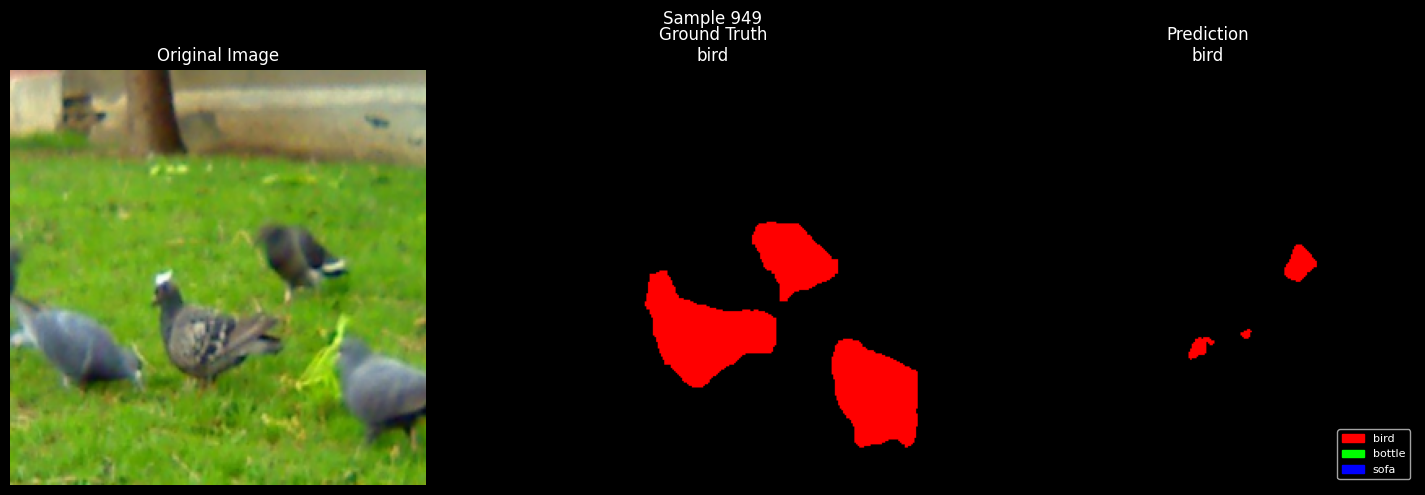

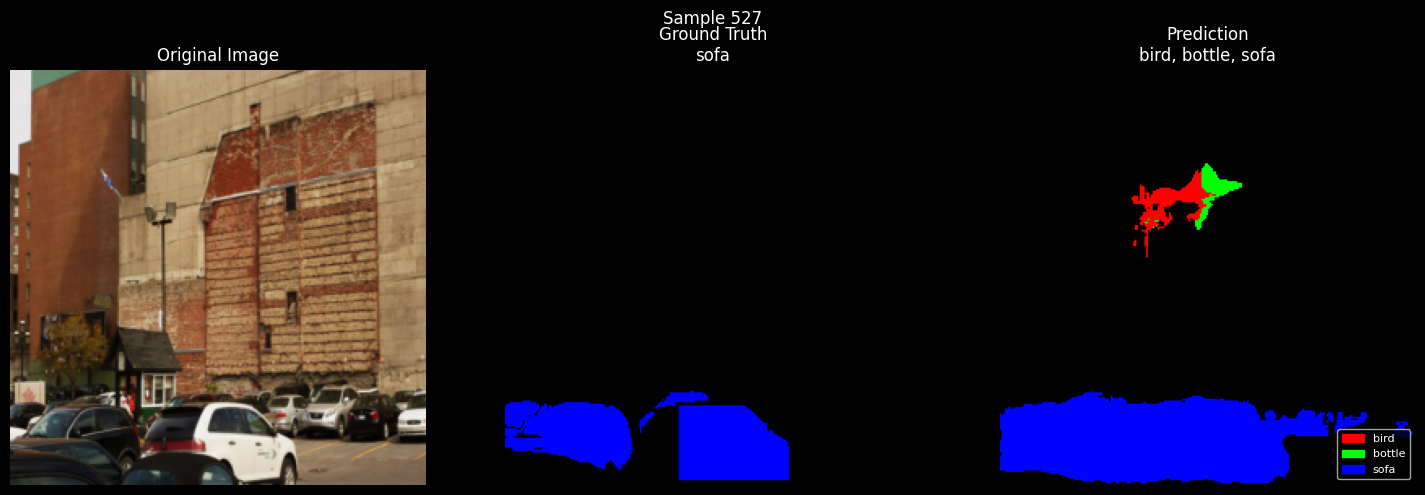

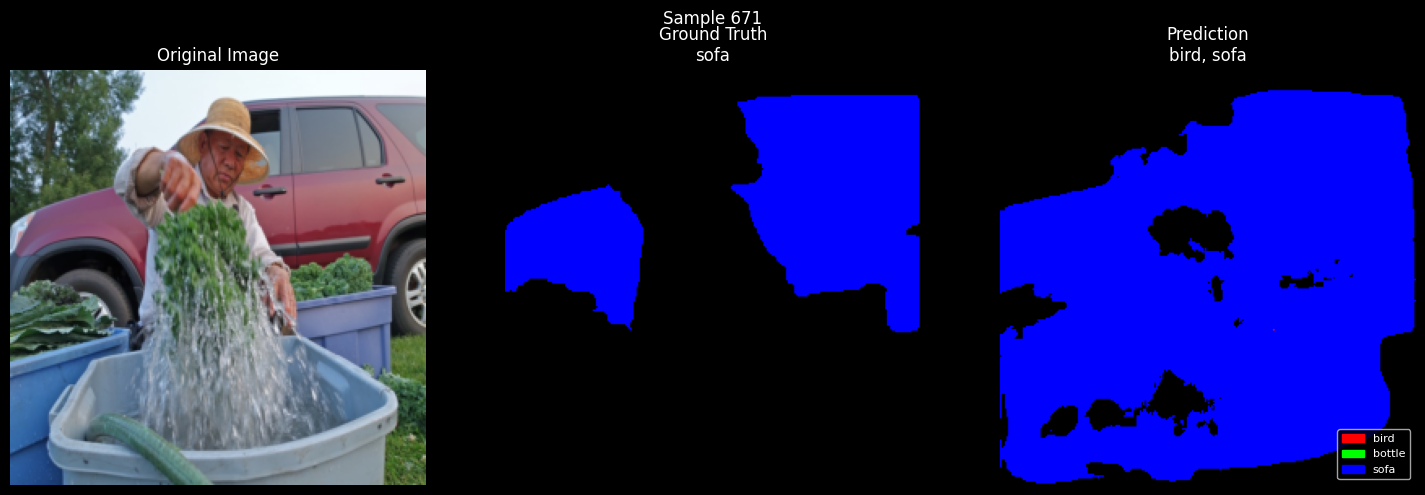

In [16]:
# Visualization Train-Val U-NET
print("Loss curves U-Net")
plot_loss_curves(train_losses, val_losses)

print("Visualizing predictions on validation set U-Net:")
visualize_predictions(model_unet, val_dataset, device, num_samples=5)

In [17]:
# Training DeepLab
deeplab_trained, train_losses_dlab, val_losses_dlab = train_model(
    model=model_deeplab,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    epochs=10,
    lr=0.0001,
    class_weights=class_weights,
    save_path='best_deeplab_model.pth'
)

Epoch 1/10 [Val]: 100%|██████████| 125/125 [00:23<00:00,  5.30it/s]



Epoch 1/10
Train Loss: 0.4991 | Val Loss: 0.3108
Val Accuracy: 0.9374
Saved best model with val loss: 0.3108


Epoch 2/10 [Val]: 100%|██████████| 125/125 [00:23<00:00,  5.34it/s]



Epoch 2/10
Train Loss: 0.3134 | Val Loss: 0.2638
Val Accuracy: 0.9436
Saved best model with val loss: 0.2638


Epoch 3/10 [Val]: 100%|██████████| 125/125 [00:23<00:00,  5.38it/s]


...


Epoch 7/10
Train Loss: 0.1647 | Val Loss: 0.2631
Val Accuracy: 0.9338
No improvement for 1 epochs


Epoch 8/10 [Val]: 100%|██████████| 125/125 [00:23<00:00,  5.38it/s]



Epoch 8/10
Train Loss: 0.1425 | Val Loss: 0.2383
Val Accuracy: 0.9265
No improvement for 2 epochs


Epoch 9/10 [Val]: 100%|██████████| 125/125 [00:23<00:00,  5.40it/s]



Epoch 9/10
Train Loss: 0.1166 | Val Loss: 0.2539
Val Accuracy: 0.9226
No improvement for 3 epochs
Early stopping at epoch 9

Training complete — best model loaded from best_deeplab_model.pth


Loss curves DeepLab


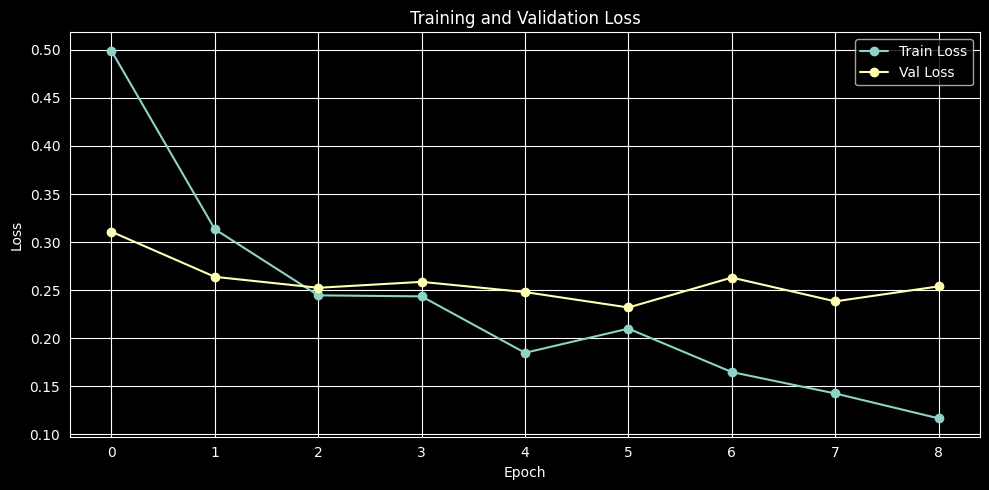

Visualizing predictions on validation set DeepLab:


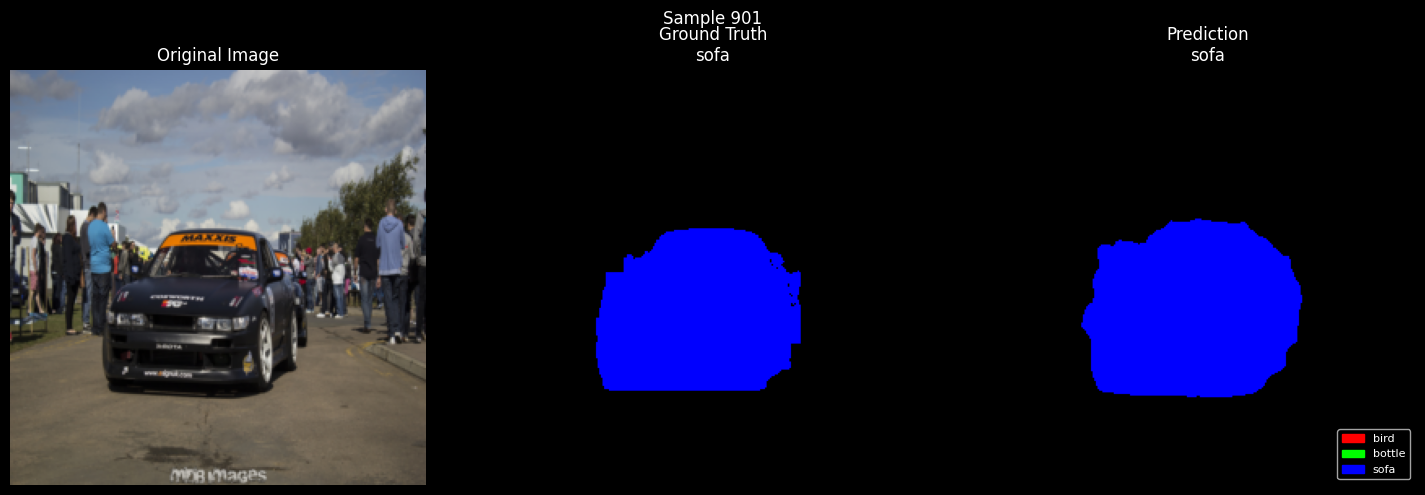

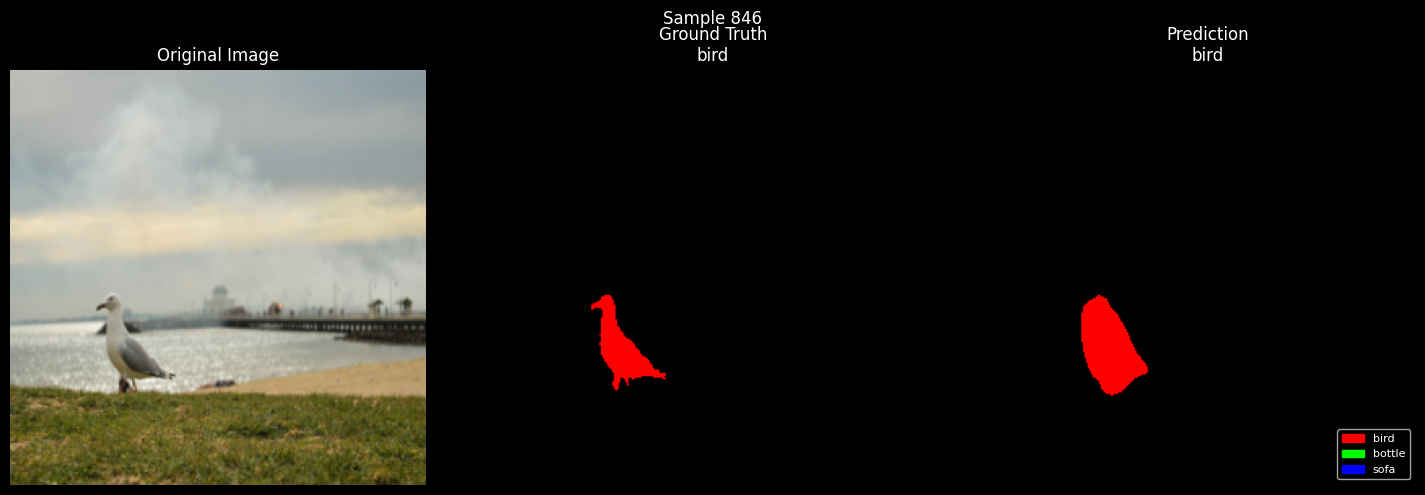

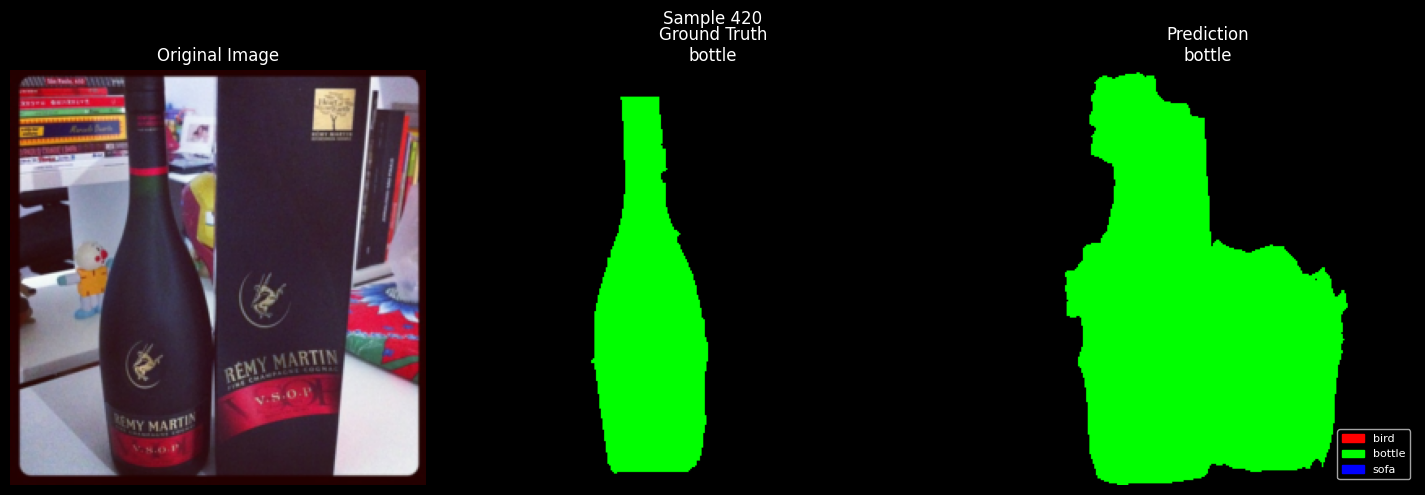

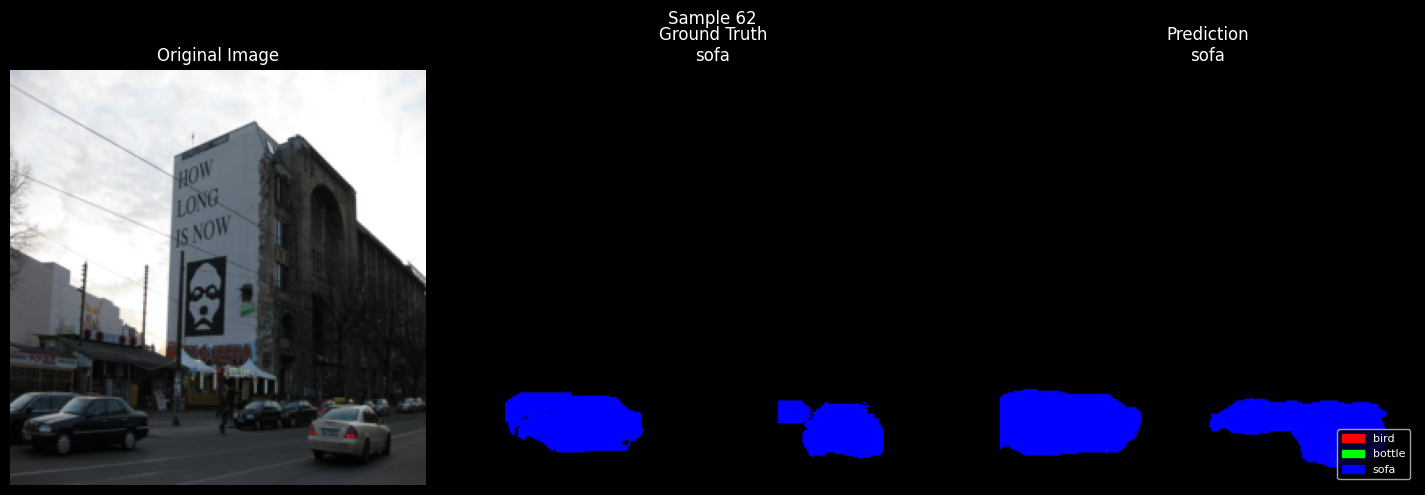

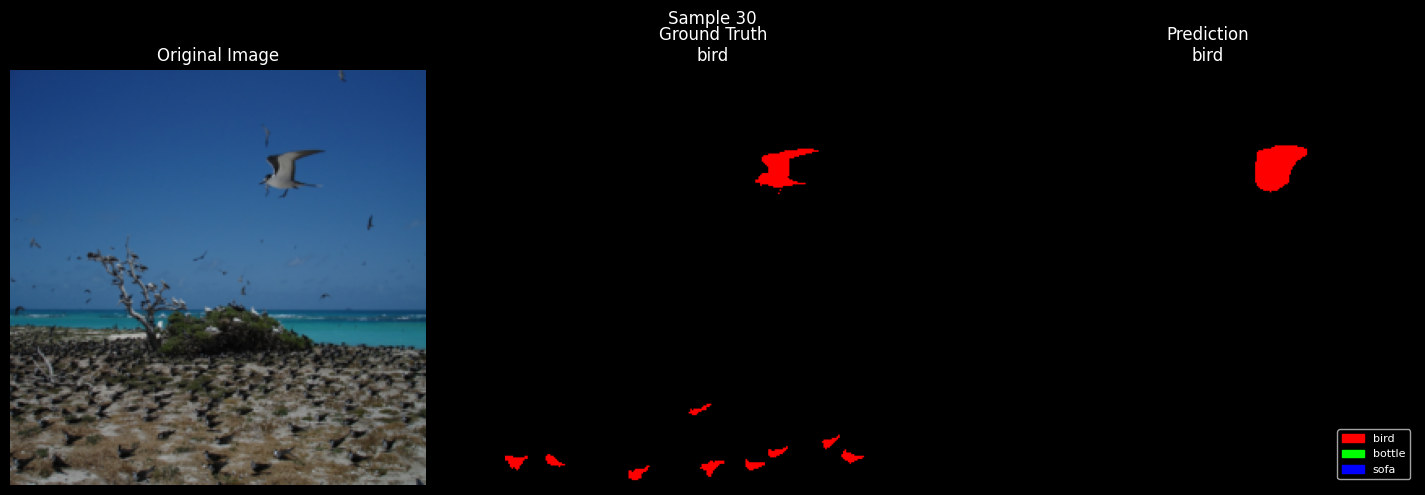

In [18]:
# Visualization Train-Val DeepLab
print("Loss curves DeepLab")
plot_loss_curves(train_losses_dlab, val_losses_dlab)

print("Visualizing predictions on validation set DeepLab:")
visualize_predictions(deeplab_trained, val_dataset, device, num_samples=5)

#### TESTING

In [19]:
# test dataset
test_fo_dataset = foz.load_zoo_dataset(
    "open-images-v7",
    split="validation",
    label_types=["segmentations"],
    max_samples=100,
    classes=["Bird", "Bottle", "Car"],
    only_matching=True,
    cleanup=True
)

INFO:fiftyone.zoo.datasets:Downloading split 'validation' to '/root/fiftyone/open-images-v7/validation' if necessary


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/validation/validation-images-with-rotation.csv' to '/root/fiftyone/open-images-v7/validation/metadata/image_ids.csv'


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/v5/class-descriptions-boxable.csv' to '/root/fiftyone/open-images-v7/validation/metadata/classes.csv'


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/v5/classes-segmentation.txt' to '/root/fiftyone/open-images-v7/validation/metadata/segmentation_classes.csv'


INFO:fiftyone.utils.openimages:Downloading 'https://storage.googleapis.com/openimages/2018_04/bbox_labels_600_hierarchy.json' to '/tmp/tmp8pwbbjxh/metadata/hierarchy.json'


...

INFO:fiftyone.zoo.datasets:Loading 'open-images-v7' split 'validation'


 100% |█████████████████| 100/100 [3.0s elapsed, 0s remaining, 35.0 samples/s]      


INFO:eta.core.utils: 100% |█████████████████| 100/100 [3.0s elapsed, 0s remaining, 35.0 samples/s]      


Dataset 'open-images-v7-validation-100' created


INFO:fiftyone.zoo.datasets:Dataset 'open-images-v7-validation-100' created


In [20]:
test_dataset = openimages_dataset(test_fo_dataset, transform=img_transformations)
test_loader  = DataLoader(test_dataset, batch_size=4, shuffle=False)

Total 100 images
Bird:     31 images
Bottle:   28 images
Car: 41 images


In [21]:
# evaluation function
def evaluate_model(model, test_loader, device):
    model.eval()

    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, gt_masks in tqdm(test_loader, desc="Evaluating"):
            images   = images.to(device)
            outputs  = model(images)
            preds    = torch.argmax(outputs, dim=1).cpu().numpy().flatten()
            labels   = gt_masks.numpy().flatten()
            all_preds.extend(preds)
            all_labels.extend(labels)

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    # exclude background from metrics
    valid = all_labels != 0

    # overall metrics
    accuracy  = accuracy_score(all_labels[valid], all_preds[valid])
    f1        = f1_score(all_labels[valid], all_preds[valid], average='macro', zero_division=0)
    precision = precision_score(all_labels[valid], all_preds[valid], average='macro', zero_division=0)
    recall    = recall_score(all_labels[valid], all_preds[valid], average='macro', zero_division=0)

    print(f"\nOverall Metrics (excluding background):")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1:        {f1:.4f}")

    # per class metrics
    classes = ['background', 'bird', 'bottle', 'car']
    print(f"\nPer Class Metrics:")
    for class_id in [1, 2, 3]:
        # evaluate class_id vs all other classes
        class_mask = (all_labels == class_id) | (all_preds == class_id)

        if np.any(class_mask):
            y_true_bin = (all_labels[class_mask] == class_id).astype(int)
            y_pred_bin = (all_preds[class_mask] == class_id).astype(int)

            class_acc = accuracy_score(y_true_bin, y_pred_bin)
            class_f1 = f1_score(
                y_true_bin,
                y_pred_bin,
                average='binary',
                zero_division=0
            )

            print(f"  {classes[class_id]}: Accuracy={class_acc:.4f}, F1={class_f1:.4f}")
        else:
            print(f"  {classes[class_id]}: no samples found")

    # confusion matrix
    cm = confusion_matrix(all_labels, all_preds, labels=[0, 1, 2, 3])
    print(f"\nConfusion Matrix:")
    print(f"{'':12} {'bg':>6} {'bird':>6} {'bottle':>6} {'car':>6}")
    for i, row_name in enumerate(['bg', 'bird', 'bottle', 'car']):
        print(f"{row_name:12} {cm[i,0]:>6} {cm[i,1]:>6} {cm[i,2]:>6} {cm[i,3]:>6}")

    return {
        'accuracy':  accuracy,
        'precision': precision,
        'recall':    recall,
        'f1':        f1
    }

--------------------------------------------------
EVALUATING U-NET
--------------------------------------------------


Evaluating: 100%|██████████| 25/25 [00:02<00:00, 11.02it/s]



Overall Metrics (excluding background):
Accuracy:  0.5514
Precision: 0.5083
Recall:    0.3316
F1:        0.3710

Per Class Metrics:
  bird: Accuracy=0.2114, F1=0.3490
  bottle: Accuracy=0.0768, F1=0.1427
  sofa bed: Accuracy=0.2951, F1=0.4557

Confusion Matrix:
                 bg   bird bottle   sofa
bg           4011050 108074 106656 1118204
bird         123500  89871  39419  33329
bottle       175974  30249  36213  80061
sofa          56814    671   2671 540844
Visualizing U-Net predictions:


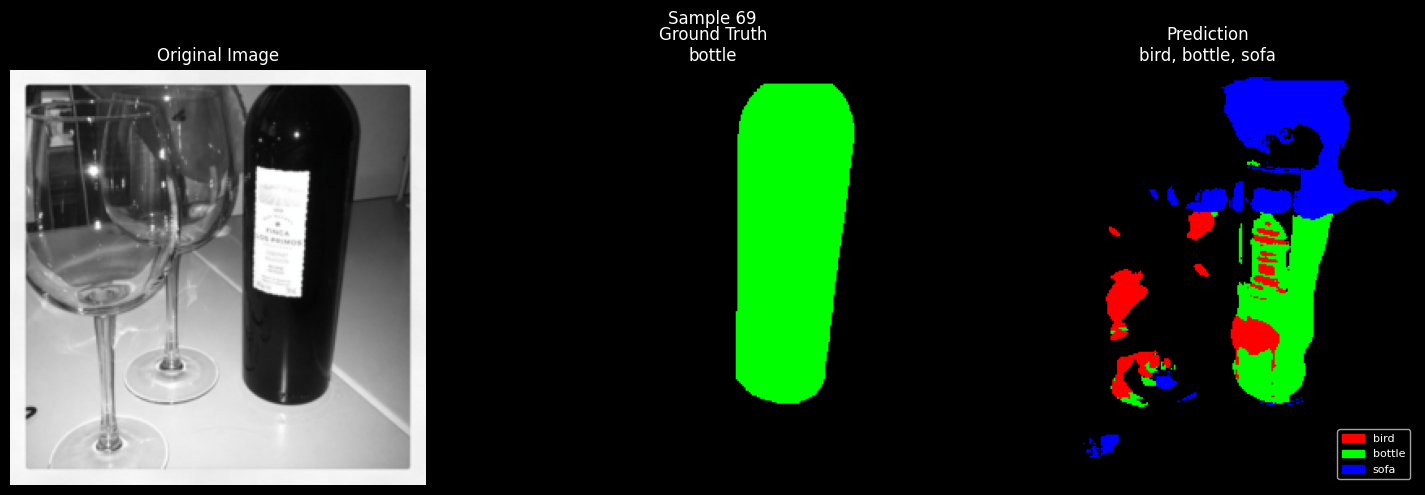

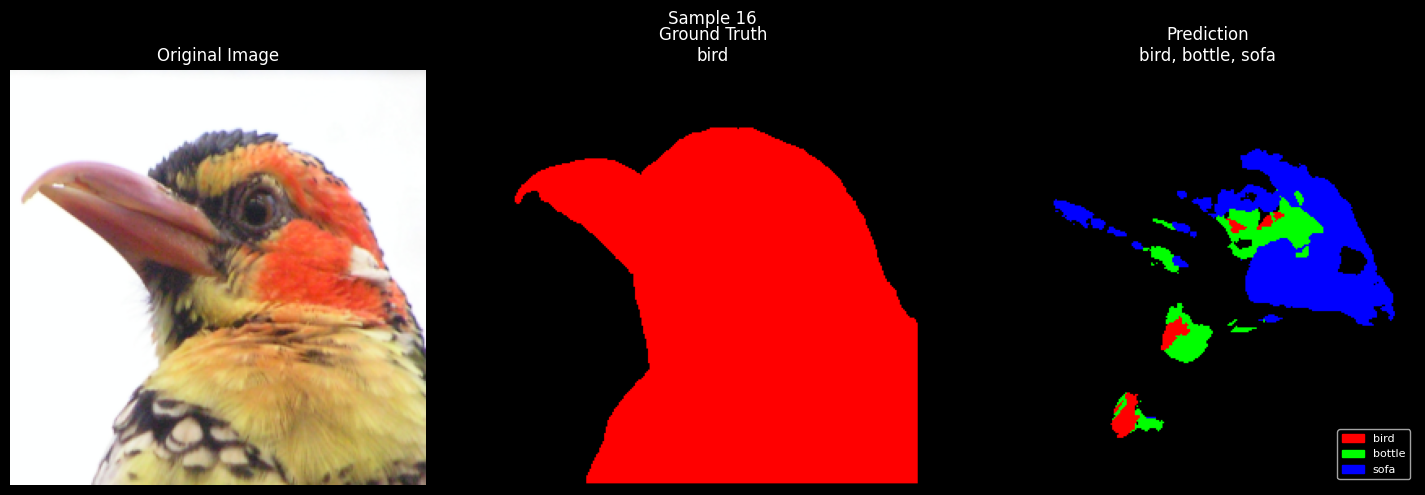

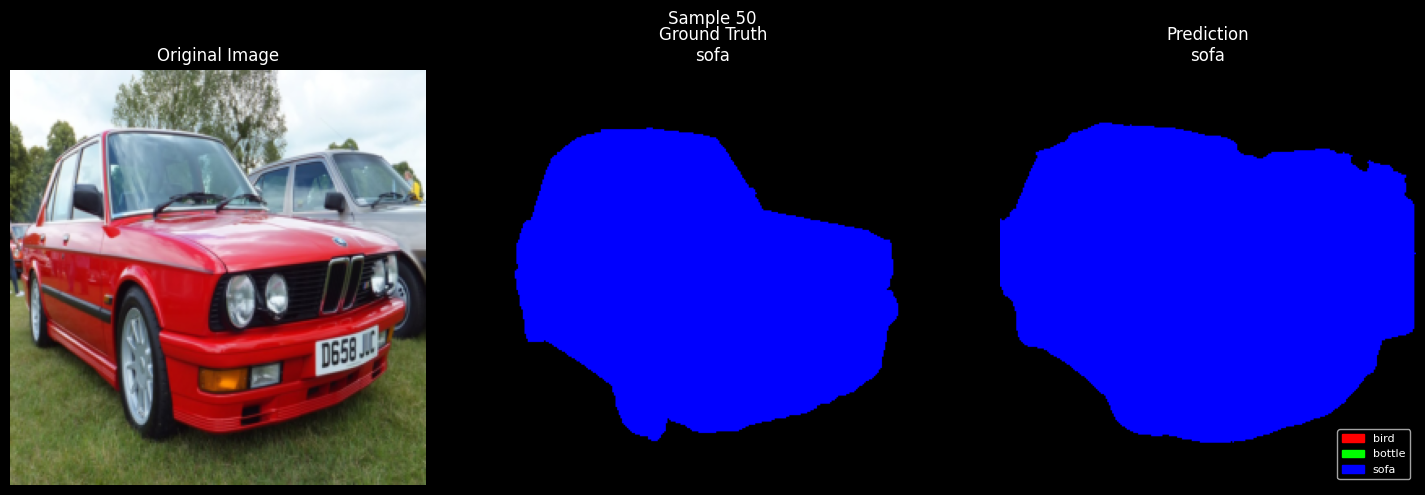

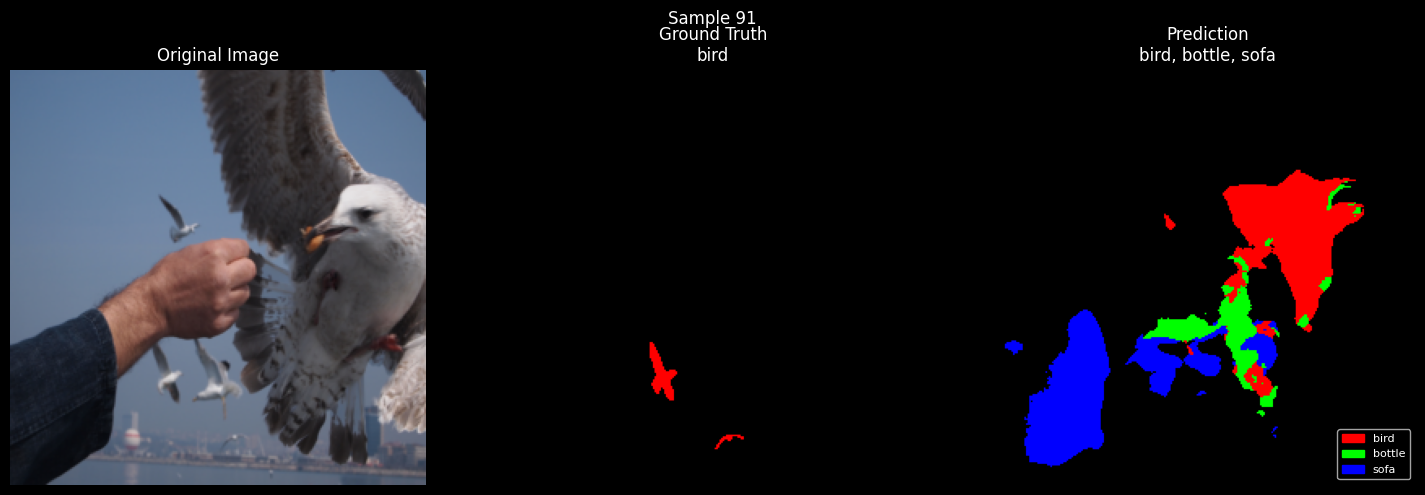

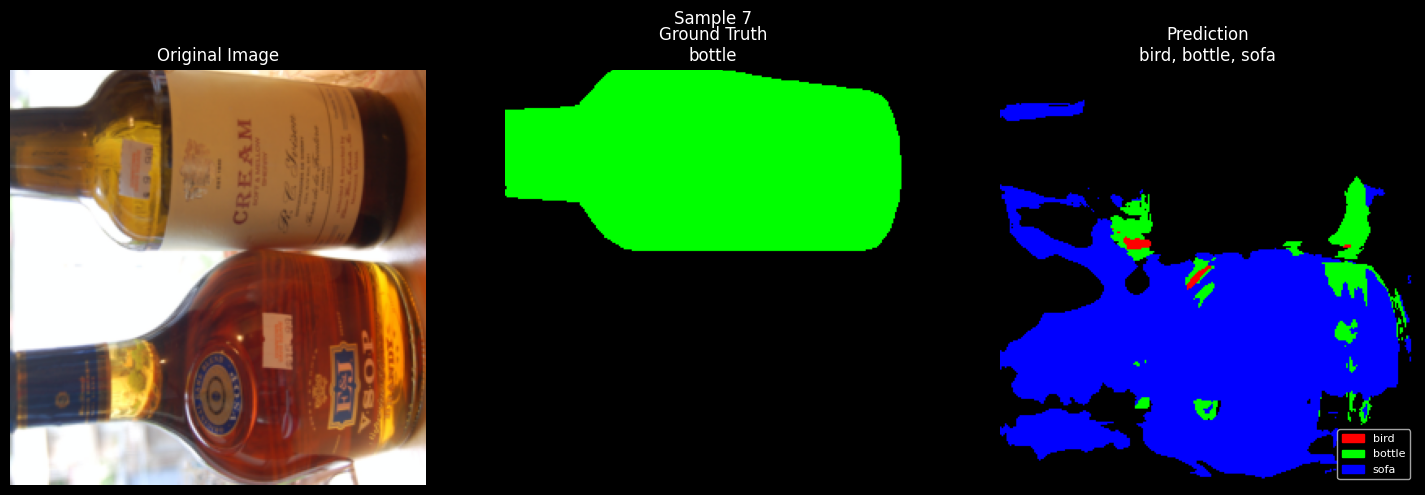

In [22]:
## testing U-NET

# loading best unet model
model_unet.load_state_dict(torch.load('best_unet_model.pth', map_location=device))

# evaluate
print("-" * 50)
print("EVALUATING U-NET")
print("-" * 50)
unet_metrics = evaluate_model(model_unet, test_loader, device)

# visualize
print("Visualizing U-Net predictions:")
visualize_predictions(model_unet, test_dataset, device, num_samples=5)

EVALUATING DEEPLABV3+


Evaluating: 100%|██████████| 25/25 [00:02<00:00, 10.13it/s]



Overall Metrics (excluding background):
Accuracy:  0.9562
Precision: 0.7494
Recall:    0.7112
F1:        0.7297

Per Class Metrics:
  bird: Accuracy=0.6065, F1=0.7551
  bottle: Accuracy=0.4364, F1=0.6076
  sofa bed: Accuracy=0.4431, F1=0.6141

Confusion Matrix:
                 bg   bird bottle   sofa
bg           4097922 158377 357700 729985
bird          16046 269610    446     17
bottle        24996     22 296999    480
sofa          11016      0      0 589984
Visualizing DeepLabV3+ predictions:


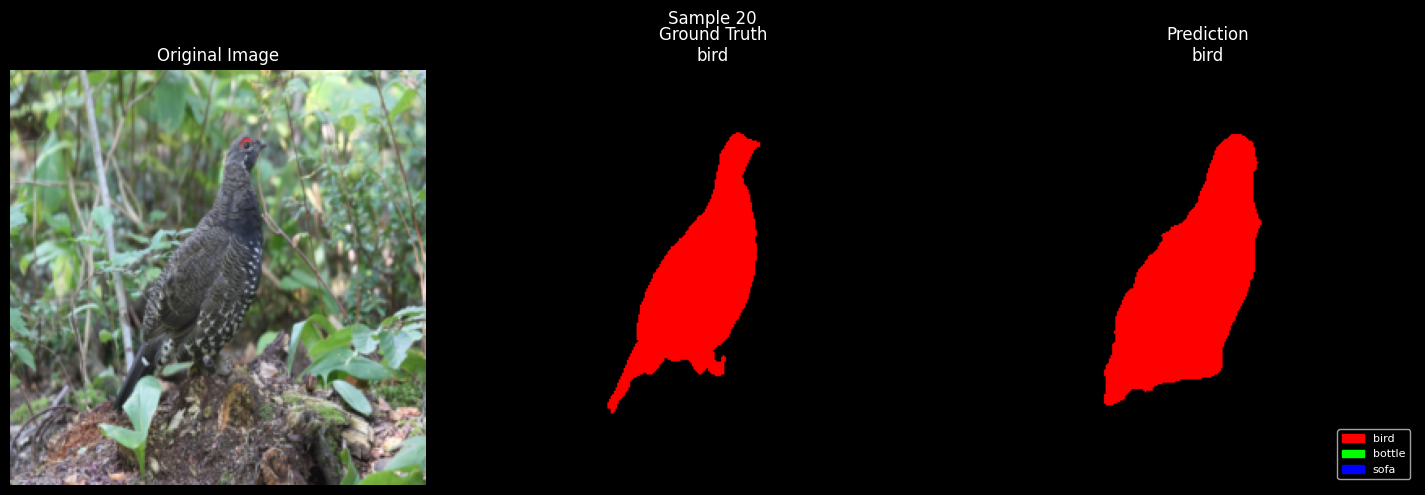

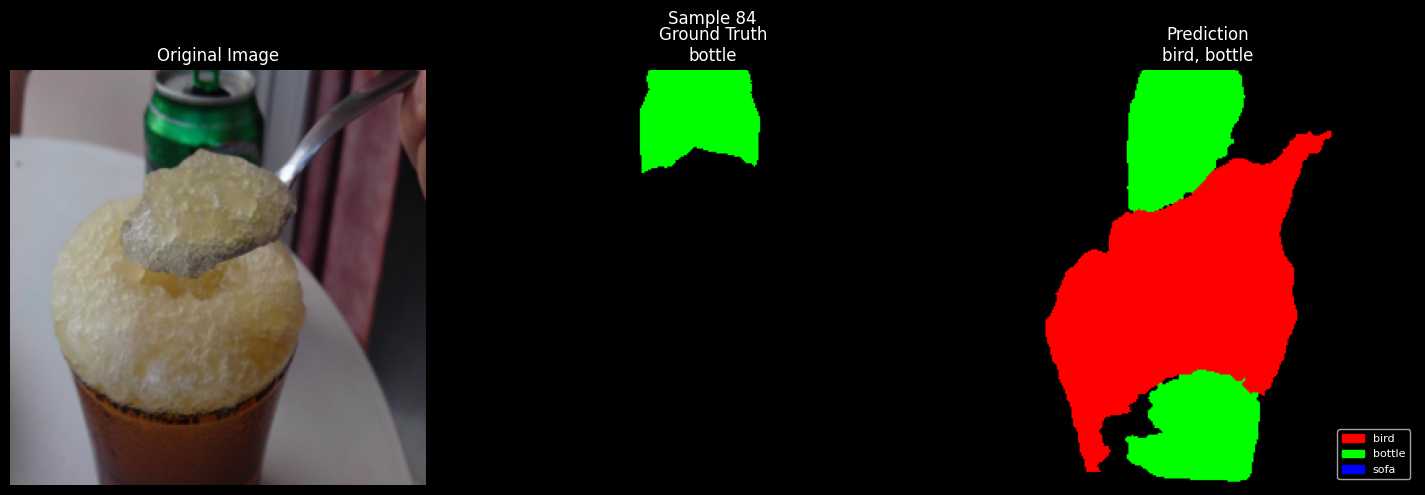

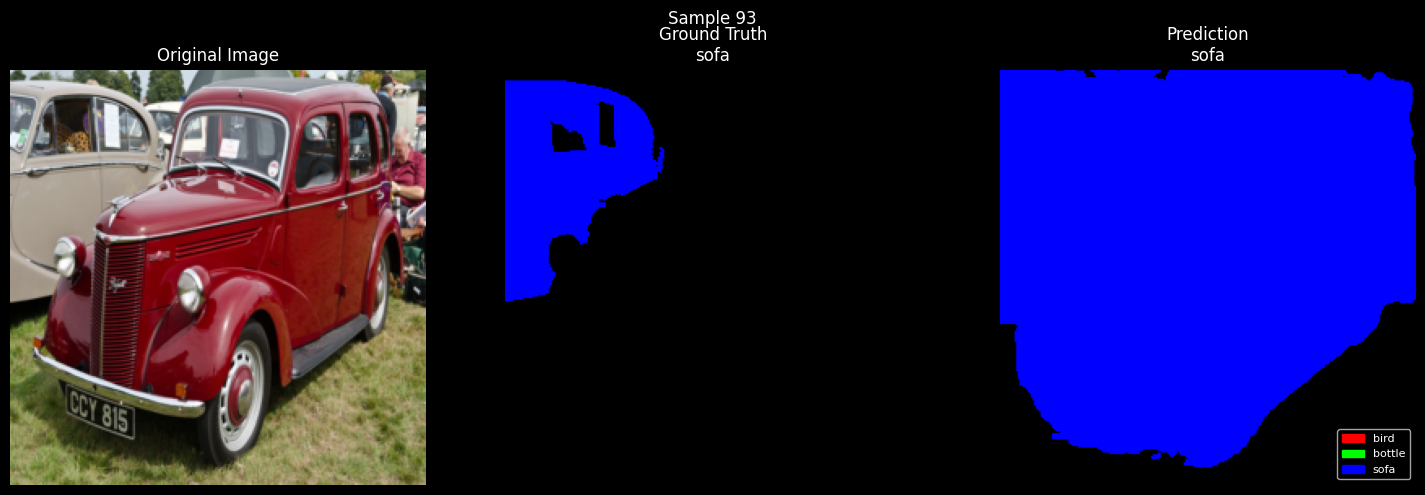

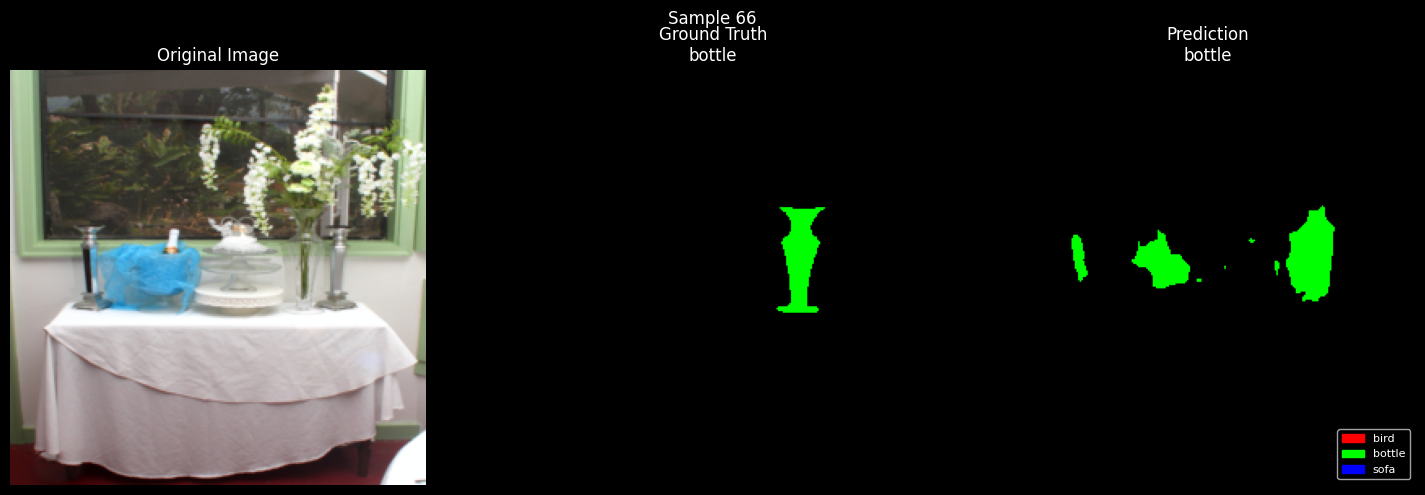

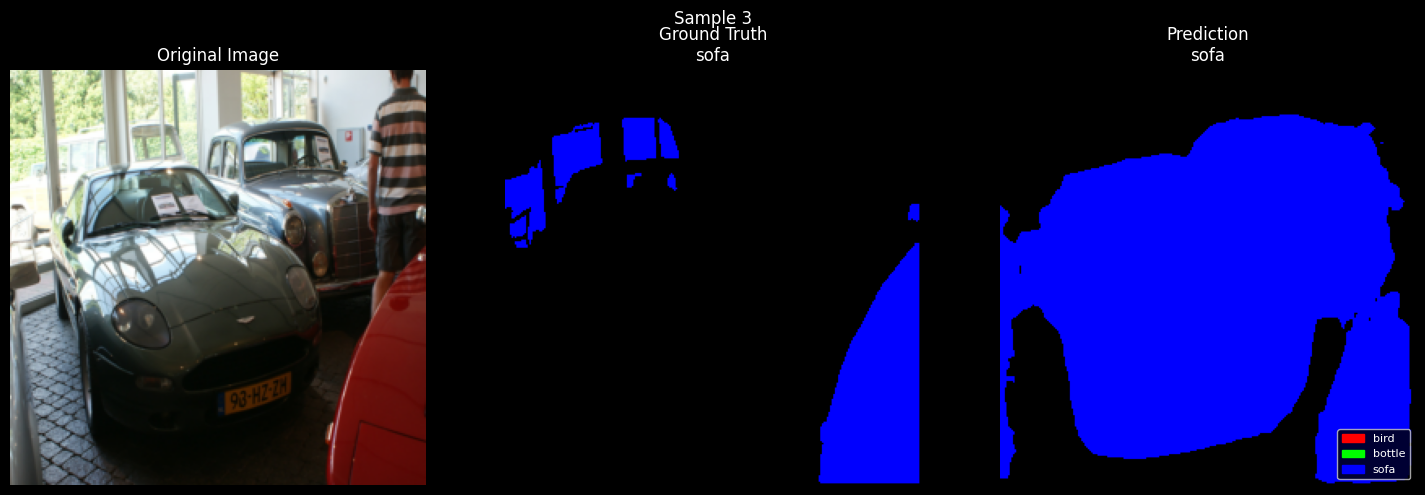

In [23]:
# testing deeplab
model_deeplab.load_state_dict(torch.load('best_deeplab_model.pth', map_location=device))

print("=" * 50)
print("EVALUATING DEEPLABV3+")
print("=" * 50)
deeplab_metrics = evaluate_model(model_deeplab, test_loader, device)

# visualize
print("Visualizing DeepLabV3+ predictions:")
visualize_predictions(model_deeplab, test_dataset, device, num_samples=5)


In [24]:
# Model comparison
print("MODEL COMPARISON")
print(f"{'Metric':12} {'Custom U-Net':>10} {'DeepLabV3+':>12}")
print("-" * 36)
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    print(f"{metric:12} {unet_metrics[metric]:>10.4f} {deeplab_metrics[metric]:>12.4f}")

MODEL COMPARISON
Metric       Custom U-Net   DeepLabV3+
------------------------------------
accuracy         0.5514       0.9562
precision        0.5083       0.7494
recall           0.3316       0.7112
f1               0.3710       0.7297
